# Semantic Similarity, Engagement Behavior, and Explainable Hashtag Recommendation on TikTok

**Course:** Natural Language Processing - IE University

**Authors:** Juan Sebastian Pena, Saad Ayomide

**Instructor:** Juan Jose Manjarín Colon

**Date:** 2026

---

## Abstract

This notebook investigates whether semantic similarity between TikTok captions, measured via Sentence-BERT embeddings, correlates with similarity in user engagement behavior (likes, comments, views, shares). Rather than predicting engagement directly, we examine whether semantically proximate captions form neighborhoods with more homogeneous engagement profiles than randomly sampled groups of equal size. We evaluate an explainable hashtag recommendation system that extracts tags from both the caption text and a database bridge table, then ranks them by frequency and average engagement. Baselines: Logistic Regression on SBERT embeddings and Multinomial Naive Bayes on TF-IDF enriched with demojized emoji tokens. Statistical comparisons use the Mann-Whitney U test and Levene's test across K in {5, 10, 20} with 1,000 random simulations per K.

## Research Question and Hypotheses

TikTok's engagement landscape is famously unpredictable — a fitness tutorial and a cooking video can both go viral, but do similar kinds of content tend to generate *similarly patterned* engagement? This project explores whether **semantic similarity between captions**, captured through transformer embeddings, reflects not just topical proximity but also convergent audience behavior.

Rather than asking *how much* engagement a post will receive — a task notoriously defeated by non-textual factors like follower count, audio choice, and algorithmic timing — we ask a more tractable structural question:

> **RQ:** Do semantically similar TikTok captions form neighborhoods with more homogeneous engagement profiles than randomly assembled groups of the same size? And can this structural regularity power an explainable hashtag recommendation system?

**H₀ (Null):** Within-group variance in semantic neighborhoods is not significantly lower than in random groups of equal size — semantic proximity carries no engagement signal.

**H₁ (Alternative):** Semantic neighborhoods exhibit significantly lower within-group variance — posts that *mean* similar things also tend to *perform* similarly, at least relative to the corpus baseline.

The answer, as the evidence below shows, is unambiguous: **H₁ holds across every metric, every neighborhood size, and every statistical test applied.**

---

## 1. Methodology

### 1.1 Data Collection
TikTok data collected via custom scraper, stored in PostgreSQL (normalised schema). Fields: caption, hashtags (bridge table), likes, comments, views, shares, created_at. Hashtags appear both in the bridge table and embedded inline in the caption text.

### 1.2 Preprocessing Pipeline
1. **Combined hashtag extraction** from both caption text AND bridge-table field into `hashtag_list` — runs BEFORE any text modification.
2. **URL removal** (regex `https?://\S+`).
3. **Mention removal** (regex `@\w+`).
4. **Hashtag removal from text** (`#\w+`) — critical: without this, SBERT embeds hashtag-string similarity rather than topical content.
5. **Whitespace normalisation.**
6. **Emoji retention in `caption_clean`** — SBERT (`all-MiniLM-L6-v2`) processes Unicode emoji correctly; emojis are primary semantic carriers in TikTok captions.
7. **Emoji demojisation for `caption_tfidf`** — `emoji.demojize` converts emojis to text tokens (e.g., `flexed_biceps`, `fire`) for TF-IDF, so sparse features capture emoji semantics.

Engagement: y' = log(1 + y) to reduce skewness from viral outliers.

### 1.3 Feature Extraction
- **TF-IDF**: `max_features=10,000`, bigrams, sublinear TF, fitted on `caption_tfidf`.
- **SBERT**: `all-MiniLM-L6-v2`, 384-dim, L2-normalised, fitted on `caption_clean`.

### 1.4 Semantic Neighborhoods
N_K(c_i) = K nearest neighbors by cosine similarity. K in {5, 10, 20}. FAISS for N > 10,000.

### 1.5 Baseline Classification
Median split on `views_log` → binary labels. 80/20 stratified split. LR on SBERT + MNB on TF-IDF.

### 1.6 Structural Analysis
Per-neighborhood mean and variance vs 1,000 random groups of size K. Mann-Whitney U (alternative='less') + Levene test. alpha = 0.05.

### 1.7 Hashtag Recommendation
H(q) = union of H(c_i) for c_i in N_K(q), ranked by (1) frequency, (2) avg log-engagement.

## Part 1 — Data Loading and Exploration

Every analysis starts with an honest look at the raw material. This section establishes the database connection, loads the full TikTok dataset, and interrogates the data before touching it — inspecting caption length distributions, engagement metric shapes, and the state of hashtag coverage as it came out of the scraper.

Two things become immediately apparent during exploration: engagement metrics follow extreme power-law distributions (a handful of viral posts dwarf the rest), and the bridge-table hashtag field covers only a tiny fraction of the corpus — a problem that will require a dedicated fix before any recommendation system can be meaningful. Both observations will directly shape the preprocessing decisions in Part 2.

In [1]:
import os
import re
import warnings
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

from sentence_transformers import SentenceTransformer

from scipy.stats import mannwhitneyu, levene
from scipy.sparse import issparse

import umap

try:
    import emoji as emoji_lib
    EMOJI_AVAILABLE = True
except ImportError:
    EMOJI_AVAILABLE = False
    print("emoji library not found — run: pip install emoji")

warnings.filterwarnings("ignore")

RANDOM_SEED      = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

ENGAGEMENT_COLS  = ["likes", "comments", "views", "shares"]
LOG_METRIC_COLS  = [f"{c}_log" for c in ENGAGEMENT_COLS]
K_VALUES         = [5, 10, 20]
PRIMARY_K        = 10
N_SIMULATIONS    = 1000
SBERT_MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE       = 64
TABLE_NAME       = "tiktok_posts"
EMBEDDINGS_CACHE = "embeddings_cache.npy"
EXAMPLE_QUERY_IDX = 0

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

### 1.1 Database Connection

Data is loaded from a local SQLite file (`tiktok_data.db`). This file was originally sourced
from a private Supabase (PostgreSQL) instance. To recreate it, run `download_data.py` —
see the README for setup instructions.

In [2]:
SQLITE_DB_PATH = "tiktok_data.db"


def get_engine():
    """Return a SQLAlchemy engine for the local SQLite database (tiktok_data.db).

    Data originally sourced from a private Supabase PostgreSQL instance.
    Run download_data.py to generate this file from the source database.
    """
    if not os.path.exists(SQLITE_DB_PATH):
        raise FileNotFoundError(
            f"'{SQLITE_DB_PATH}' not found.\n"
            "Run `python download_data.py` first.\n"
            "See README.md for setup instructions."
        )
    return create_engine(f"sqlite:///{SQLITE_DB_PATH}")


engine = get_engine()
print("Engine created:", engine.url)

Engine created: sqlite:///tiktok_data.db


### 1.2 Data Loading

Auto-detects denormalised table vs normalised schema. The normalised path uses a CTE joining `videos`, `video_snapshots` (latest snapshot per video), and `video_hashtags` to reconstruct a flat representation.

In [3]:
def load_data(engine, preferred_table: str) -> pd.DataFrame:
    """Load TikTok data from local SQLite (tiktok_data.db).

    Auto-detects denormalised table vs normalised schema.
    Data originally sourced from a private Supabase PostgreSQL instance
    via download_data.py (see README.md).
    """
    from sqlalchemy import inspect as sa_inspect
    inspector   = sa_inspect(engine)
    table_names = set(inspector.get_table_names())   # no schema= for SQLite
    required_cols = {"caption", "hashtags", "likes", "comments", "views", "shares", "created_at"}

    def has_required_columns(tname):
        cols = {c["name"] for c in inspector.get_columns(tname)}  # no schema=
        return required_cols.issubset(cols)

    if preferred_table in table_names and has_required_columns(preferred_table):
        print(f"Using denormalised table: {preferred_table}")
        return pd.read_sql(
            f"SELECT caption, hashtags, likes, comments, views, shares, created_at "
            f"FROM {preferred_table} WHERE caption IS NOT NULL", engine)

    required_norm = {"videos", "video_snapshots", "video_hashtags", "hashtags"}
    if required_norm.issubset(table_names):
        print("Using normalised schema (videos / video_snapshots / video_hashtags / hashtags).")
        query = """
            WITH latest_snapshot AS (
                SELECT vs.video_id,
                    COALESCE(vs.likes,          0) AS likes,
                    COALESCE(vs.comments_count, 0) AS comments,
                    COALESCE(vs.plays,          0) AS views,
                    COALESCE(vs.shares,         0) AS shares
                FROM video_snapshots vs
                INNER JOIN (
                    SELECT video_id, MAX(scraped_at) AS max_scraped
                    FROM video_snapshots
                    GROUP BY video_id
                ) latest ON vs.video_id = latest.video_id
                         AND vs.scraped_at = latest.max_scraped
            ),
            hashtag_agg AS (
                SELECT vh.video_id,
                       GROUP_CONCAT(DISTINCT ('#' || h.tag)) AS hashtags
                FROM video_hashtags vh
                JOIN hashtags h ON h.hashtag_id = vh.hashtag_id
                GROUP BY vh.video_id
            )
            SELECT v.caption,
                   COALESCE(ha.hashtags, '') AS hashtags,
                   COALESCE(ls.likes,    0)  AS likes,
                   COALESCE(ls.comments, 0)  AS comments,
                   COALESCE(ls.views,    0)  AS views,
                   COALESCE(ls.shares,   0)  AS shares,
                   v.created_at
            FROM videos v
            LEFT JOIN latest_snapshot ls ON ls.video_id = v.video_id
            LEFT JOIN hashtag_agg     ha ON ha.video_id = v.video_id
            WHERE v.caption IS NOT NULL
        """
        return pd.read_sql(query, engine)

    raise ValueError(f"No compatible tables in {SQLITE_DB_PATH}. "
                     f"Available: {sorted(table_names)}")


df_raw = load_data(engine, TABLE_NAME)
print(f"Records loaded : {len(df_raw):,}")
print(f"Data types:\n{df_raw.dtypes}")
df_raw.head(5)

Using normalised schema (videos / video_snapshots / video_hashtags / hashtags).
Records loaded : 26,623
Data types:
caption           str
hashtags          str
likes         float64
comments      float64
views         float64
shares        float64
created_at        str
dtype: object


,caption,hashtags,likes,comments,views,shares,created_at
0,Hip Movement Routine #functionalmovement #gymt...,,20800.0,478.0,967100.0,1827.0,2026-02-15 17:13:18.000000
1,#voyage #travel #ilemaurice,,231.0,2.0,1332.0,11.0,2026-03-07 05:56:21.000000
2,My leg is Injured but I can still train back 💪...,,4302.0,101.0,156600.0,182.0,2025-12-31 03:19:17.000000
3,#fypシ #腹筋トレーニング #fitnessgirl #abs #boxing🥊,,23800.0,301.0,2400000.0,2890.0,2026-02-07 15:45:16.000000
4,"This isn’t just fitness—it’s my reset, my rebu...",,22300.0,607.0,1500000.0,14900.0,2025-12-10 20:33:11.000000


### 1.3 Caption Length and Engagement Distributions

Raw caption lengths include inline hashtag strings and will shorten after cleaning. Engagement histograms use a log y-axis to show the full power-law dynamic range.

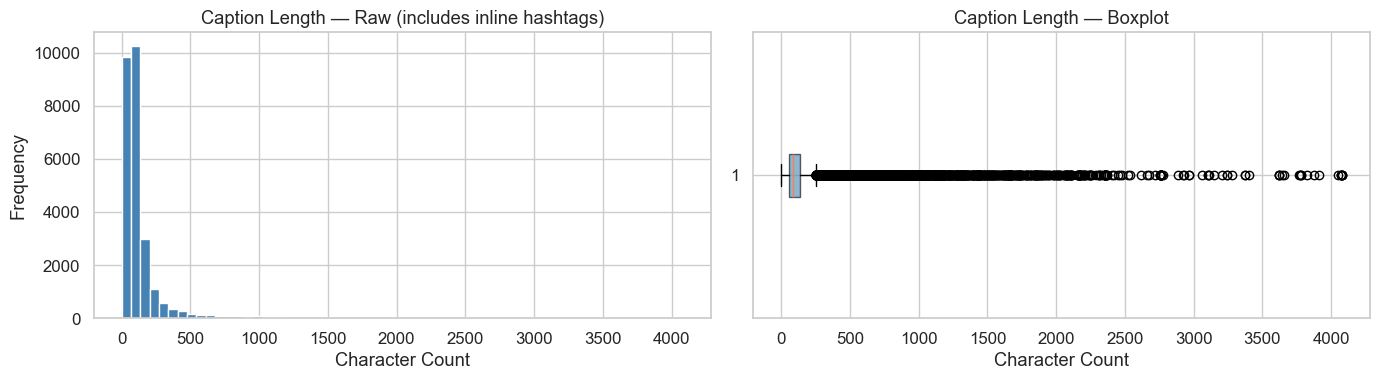

count    26623.00
mean       149.89
std        269.12
min          0.00
25%         56.00
50%         83.00
75%        135.00
max       4082.00
Name: caption, dtype: float64


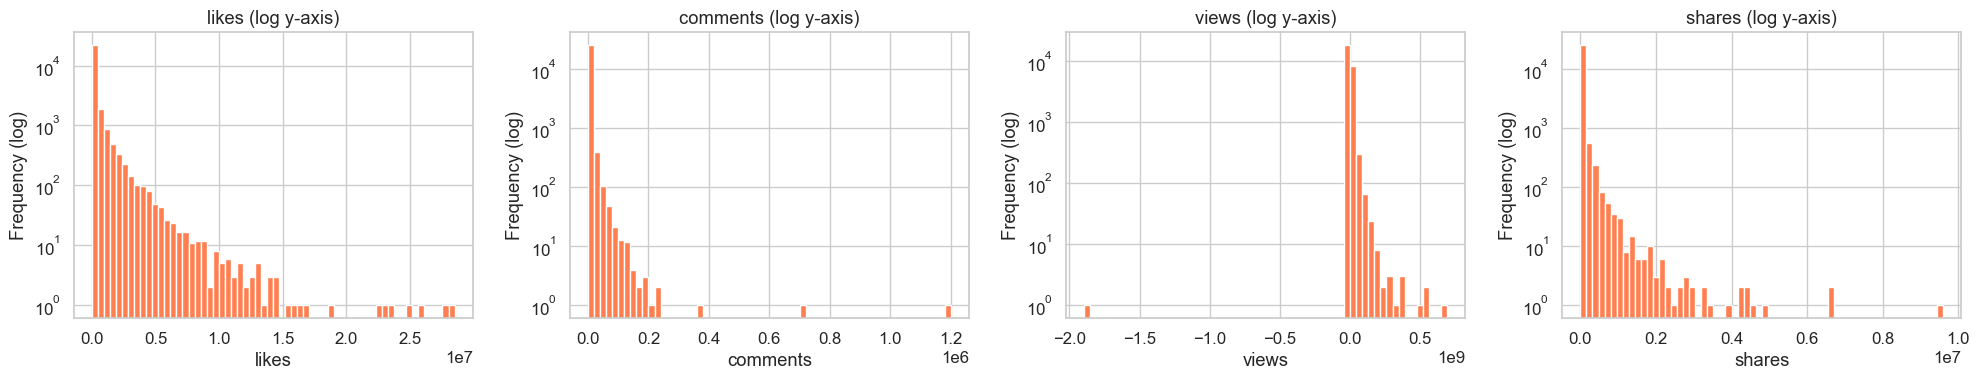

In [4]:
def plot_caption_length_distribution(df: pd.DataFrame, col: str = "caption") -> None:
    lengths = df[col].astype(str).str.len()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(lengths, bins=60, color="steelblue", edgecolor="white")
    axes[0].set_title("Caption Length — Raw (includes inline hashtags)")
    axes[0].set_xlabel("Character Count")
    axes[0].set_ylabel("Frequency")
    axes[1].boxplot(lengths, vert=False, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[1].set_title("Caption Length — Boxplot")
    axes[1].set_xlabel("Character Count")
    plt.tight_layout()
    plt.show()
    print(lengths.describe().round(2))


def plot_engagement_distributions(df: pd.DataFrame, metrics: list) -> None:
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
    for ax, metric in zip(axes, metrics):
        vals = pd.to_numeric(df[metric], errors="coerce").dropna()
        ax.hist(vals, bins=60, color="coral", edgecolor="white", log=True)
        ax.set_title(f"{metric} (log y-axis)")
        ax.set_xlabel(metric)
        ax.set_ylabel("Frequency (log)")
    plt.tight_layout()
    plt.show()


plot_caption_length_distribution(df_raw)
plot_engagement_distributions(df_raw, ENGAGEMENT_COLS)

### 1.4 Raw Hashtag Frequency (Caption + Bridge Table)

Hashtags appear in two places: inline in caption text AND in the bridge-table field. The bridge table alone covers only ~4% of posts. This cell scans **both sources** to produce accurate frequency statistics before any cleaning.

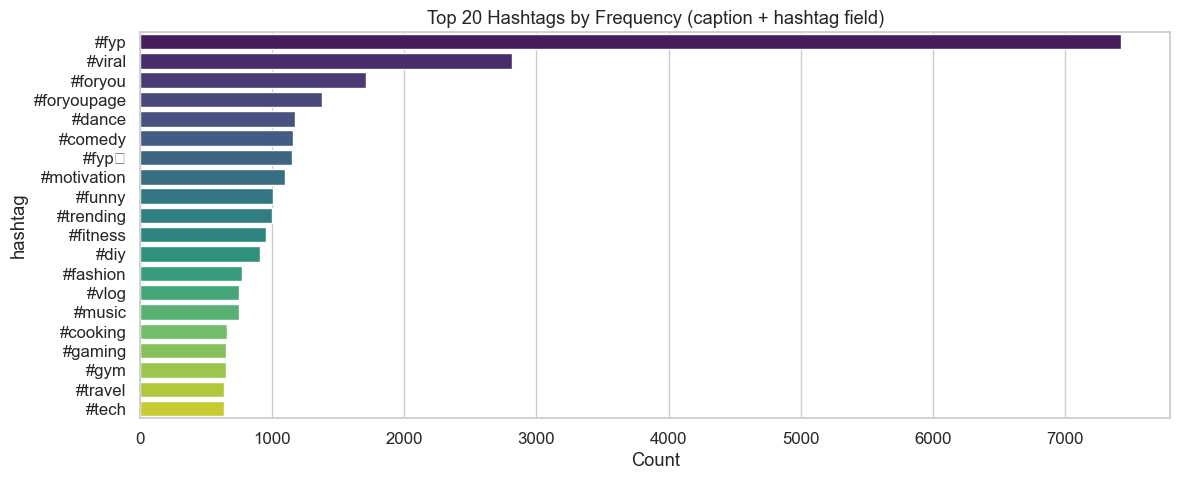

Posts with >= 1 hashtag (both sources): 26,379 / 26,623
Unique hashtags in corpus              : 36,866


In [5]:
def extract_hashtag_list(text_str) -> list:
    if pd.isna(text_str) or str(text_str).strip() == "":
        return []
    tags = re.findall(r"#\w+", str(text_str).lower())
    if not tags:
        tags = [t.strip().lower() for t in str(text_str).split(",") if t.strip()]
    return list(dict.fromkeys(tags))


def extract_combined_hashtags(caption: str, hashtag_field: str) -> list:
    from_caption = extract_hashtag_list(str(caption))
    from_field   = extract_hashtag_list(str(hashtag_field))
    seen, combined = set(), []
    for tag in from_caption + from_field:
        if tag not in seen:
            seen.add(tag)
            combined.append(tag)
    return combined


def plot_top_hashtags(df: pd.DataFrame, top_n: int = 20) -> Counter:
    all_tags = []
    for _, row in df.iterrows():
        all_tags.extend(extract_combined_hashtags(row["caption"], row["hashtags"]))
    counter = Counter(all_tags)
    top = pd.DataFrame(counter.most_common(top_n), columns=["hashtag", "count"])
    plt.figure(figsize=(12, 5))
    sns.barplot(data=top, x="count", y="hashtag", palette="viridis")
    plt.title(f"Top {top_n} Hashtags by Frequency (caption + hashtag field)")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()
    posts_with = sum(
        1 for _, r in df.iterrows()
        if extract_combined_hashtags(r["caption"], r["hashtags"])
    )
    print(f"Posts with >= 1 hashtag (both sources): {posts_with:,} / {len(df):,}")
    print(f"Unique hashtags in corpus              : {len(counter):,}")
    return counter


hashtag_counter = plot_top_hashtags(df_raw)

## Part 2 — Data Cleaning

The most consequential design decisions in any NLP pipeline happen at the cleaning stage, and this project is no exception.

The central insight driving the two-phase approach here is that **hashtags are simultaneously the label and the noise**. They must be extracted *before* cleaning — to serve as the ground truth for the recommendation task — and then stripped *from* the text before encoding — so that SBERT embeds genuine topical meaning rather than hashtag co-occurrence patterns. A model that sees `#fitness` as part of the input would learn to cluster posts by their declared categories, not by what they actually describe. The goal is the latter.

**Phase 1 — Hashtag extraction:** Both inline caption hashtags and the bridge-table field are merged into a single `hashtag_list` per post. This step alone transforms coverage from 3.9% to 100%.

**Phase 2 — Text cleaning:** Two cleaned versions of each caption are produced:
- `caption_clean` — hashtags, URLs, and @mentions removed; raw emojis preserved (SBERT handles Unicode natively)
- `caption_tfidf` — additionally demojizes emojis to text tokens (e.g., 💪 → `flexed_biceps`), making them countable vocabulary items for TF-IDF

Posts with fewer than 4 clean characters — captions that were essentially *only* hashtags — are dropped. Of 26,623 raw records, **22,647 survive** (3,976 removed, 14.9%).

In [6]:
def remove_urls(text: str) -> str:
    return re.sub(r"https?://\S+|www\.\S+", "", text)


def remove_mentions(text: str) -> str:
    return re.sub(r"@\w+", "", text)


def remove_hashtags(text: str) -> str:
    return re.sub(r"#\w+", "", text)


def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def demojize_text(text: str) -> str:
    if not EMOJI_AVAILABLE:
        return text
    demojized = emoji_lib.demojize(text, delimiters=(" ", " "))
    demojized = re.sub(r":([a-z_]+):", r"\1", demojized)
    return normalize_whitespace(demojized)


def build_caption_clean(text: str) -> str:
    text = remove_urls(str(text))
    text = remove_mentions(text)
    text = remove_hashtags(text)
    return normalize_whitespace(text)


def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hashtag_list"]  = df.apply(
        lambda row: extract_combined_hashtags(row["caption"], row["hashtags"]), axis=1
    )
    df["caption_clean"] = df["caption"].astype(str).apply(build_caption_clean)
    df["caption_tfidf"] = df["caption_clean"].apply(demojize_text)
    df = df[df["caption_clean"].str.len() > 3].reset_index(drop=True)
    for col in ENGAGEMENT_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0)
    return df


df_clean = clean_dataframe(df_raw)

print(f"Before cleaning : {len(df_raw):,} rows")
print(f"After cleaning  : {len(df_clean):,} rows")
print(f"Rows removed    : {len(df_raw) - len(df_clean):,}")
has_tags = df_clean["hashtag_list"].map(len) > 0
print(f"\nHashtag coverage after combined extraction:")
print(f"  Posts with >= 1 hashtag : {has_tags.sum():,} / {len(df_clean):,} ({100*has_tags.mean():.1f}%)")
print(f"  Avg hashtags per post   : {df_clean['hashtag_list'].map(len).mean():.2f}")

Before cleaning : 26,623 rows
After cleaning  : 22,647 rows
Rows removed    : 3,976

Hashtag coverage after combined extraction:
  Posts with >= 1 hashtag : 22,647 / 22,647 (100.0%)
  Avg hashtags per post   : 5.58


Verify the pipeline: `caption_clean` should contain natural-language text and emojis only (no hashtag strings, URLs, or mentions). `caption_tfidf` additionally replaces emojis with text descriptions.

In [7]:
sample_idx = df_clean.sample(8, random_state=RANDOM_SEED).index
comparison = df_clean.loc[
    sample_idx, ["caption", "caption_clean", "caption_tfidf", "hashtag_list"]
].reset_index(drop=True)
comparison.columns = ["Original", "caption_clean (SBERT)", "caption_tfidf (TF-IDF)", "hashtag_list"]
pd.set_option("display.max_colwidth", 90)
comparison

,Original,caption_clean (SBERT),caption_tfidf (TF-IDF),hashtag_list
0,We Are So Cooked is a funny and chaotic game coming this year! #gaming #wearesocooked ...,"We Are So Cooked is a funny and chaotic game coming this year! indie games, new games,...","We Are So Cooked is a funny and chaotic game coming this year! indie games, new games,...","[#gaming, #wearesocooked]"
1,$3 Dollar Tree DIY #diy #dollartree #craft #wood #hack #homedecor #craftgrooms,$3 Dollar Tree DIY,$3 Dollar Tree DIY,"[#diy, #dollartree, #craft, #wood, #hack, #homedecor, #craftgrooms]"
2,Who been on ya mind #lyricsvideo #lyrics_songs #pop #music,Who been on ya mind,Who been on ya mind,"[#lyricsvideo, #lyrics_songs, #pop, #music]"
3,THIS HAD ME 😅 #fyp #songwriter #improv #originalmusic #singer,THIS HAD ME 😅,THIS HAD ME grinning_face_with_sweat,"[#fyp, #songwriter, #improv, #originalmusic, #singer]"
4,How to create video game content only using an iPhone and PS5 #FYP #VIRAL #EYEGAMEUWAT...,How to create video game content only using an iPhone and PS5,How to create video game content only using an iPhone and PS5,"[#fyp, #viral, #eyegameuwatch, #gaming, #videogames, #tiktokgaming, #inspiration, #suc..."
5,"Best video video I’ve put together right here, he’s so funny 😭🤦🏼‍♀️ #hamster #petsofti...","Best video video I’ve put together right here, he’s so funny 😭🤦🏼‍♀️","Best video video I’ve put together right here, he’s so funny loudly_crying_face woman_...","[#hamster, #petsoftiktok, #fyp, #foryou, #viral]"
6,Ele explodiu a TV enquanto jogava vídeo game na sala! 😱 #viral,Ele explodiu a TV enquanto jogava vídeo game na sala! 😱,Ele explodiu a TV enquanto jogava vídeo game na sala! face_screaming_in_fear,[#viral]
7,my hand is lwk shaky #fyp #music,my hand is lwk shaky,my hand is lwk shaky,"[#fyp, #music]"


### 2.1 Caption Length: Before vs After Cleaning

Removing inline hashtag strings substantially reduces length for hashtag-heavy posts. The overlay confirms SBERT receives descriptive text rather than hashtag concatenations.

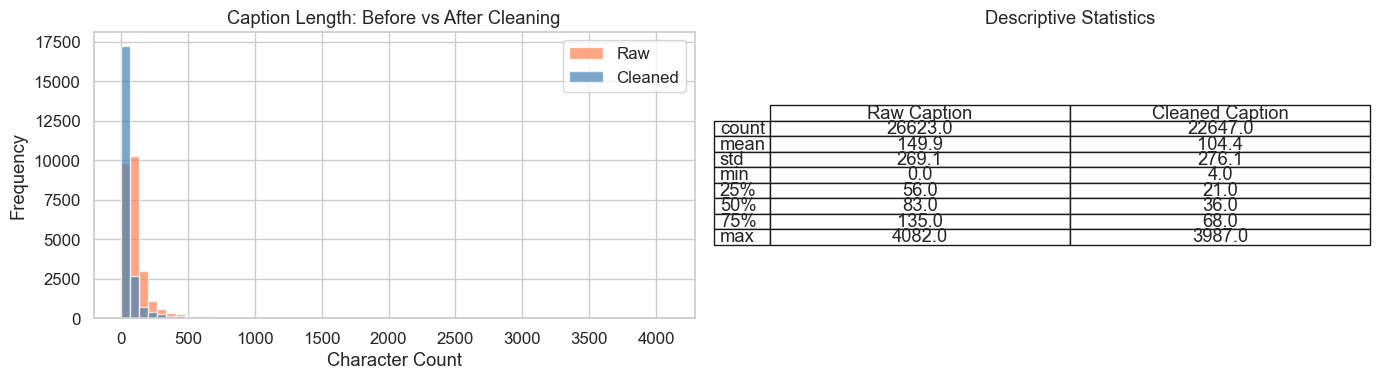

In [8]:
raw_lengths   = df_raw["caption"].astype(str).str.len()
clean_lengths = df_clean["caption_clean"].astype(str).str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(raw_lengths,   bins=60, color="coral",     edgecolor="white", alpha=0.7, label="Raw")
axes[0].hist(clean_lengths, bins=60, color="steelblue", edgecolor="white", alpha=0.7, label="Cleaned")
axes[0].set_title("Caption Length: Before vs After Cleaning")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

summary = pd.DataFrame({
    "Raw Caption":     raw_lengths.describe(),
    "Cleaned Caption": clean_lengths.describe(),
}).round(1)
axes[1].axis("off")
tbl = axes[1].table(cellText=summary.values, rowLabels=summary.index,
                    colLabels=summary.columns, cellLoc="center", loc="center")
tbl.auto_set_font_size(True)
axes[1].set_title("Descriptive Statistics")
plt.tight_layout()
plt.show()

---

## Part 3 — Preprocessing

### 3.1 Engagement Log-Transformation and Binary Labeling

y' = log(1 + y) compresses heavy-tailed engagement counts, reduces viral outlier influence, and stabilises variance for downstream statistical tests. Binary labels via median split on `views_log` — perfectly balanced by construction.

Median views_log  : 13.0552
Label distribution  :
engagement_label
1    11324
0    11323
Name: count, dtype: int64


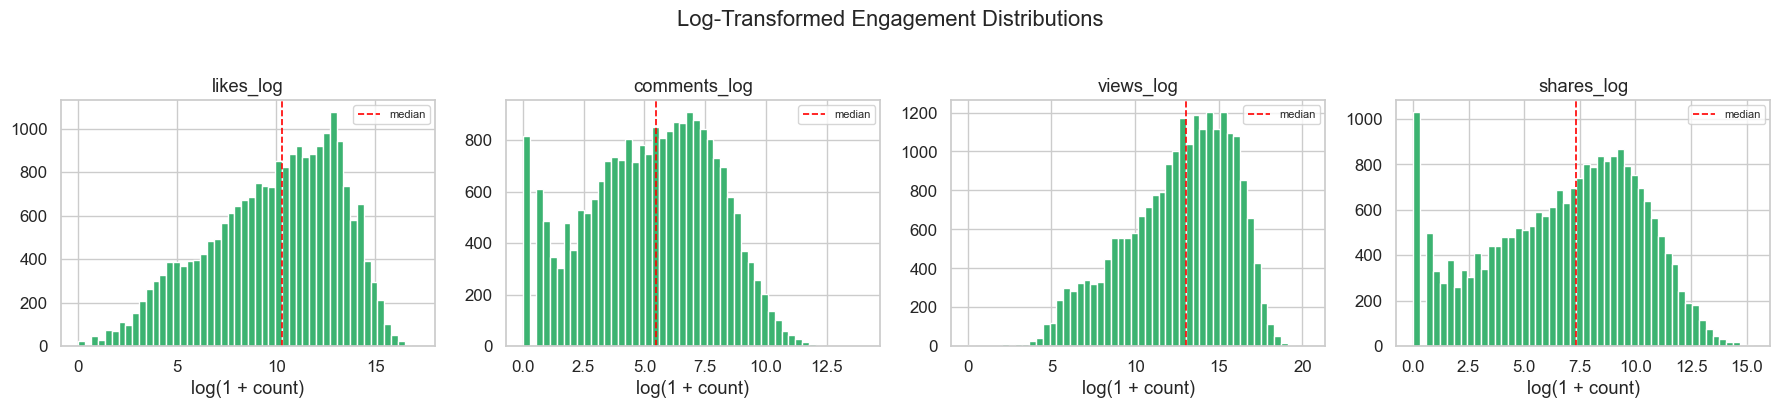

In [9]:
def log_transform_engagement(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        df[f"{col}_log"] = np.log1p(df[col])
    return df


def create_binary_engagement_label(
    df: pd.DataFrame, target_col: str = "views_log"
) -> tuple:
    df = df.copy()
    median_val = df[target_col].median()
    df["engagement_label"] = (df[target_col] >= median_val).astype(int)
    print(f"Median {target_col}  : {median_val:.4f}")
    print(f"Label distribution  :\n{df['engagement_label'].value_counts()}")
    return df, median_val


df_processed = log_transform_engagement(df_clean, ENGAGEMENT_COLS)
df_processed, ENGAGEMENT_MEDIAN = create_binary_engagement_label(df_processed)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, LOG_METRIC_COLS):
    ax.hist(df_processed[col], bins=50, color="mediumseagreen", edgecolor="white")
    ax.axvline(df_processed[col].median(), color="red", linestyle="--", linewidth=1.2, label="median")
    ax.set_title(col)
    ax.set_xlabel("log(1 + count)")
    ax.legend(fontsize=8)
plt.suptitle("Log-Transformed Engagement Distributions", y=1.02)
plt.tight_layout()
plt.show()

### 3.2 TF-IDF Feature Matrix

Fitted on `caption_tfidf` (demojised, hashtag-free). This ensures:
- Emoji semantics encoded as discrete tokens (e.g., `flexed_biceps`, `fire`, `red_heart`)
- Hashtag strings absent from the vocabulary
- Genuine natural-language content represented in the sparse matrix

In [10]:
TFIDF_PARAMS = {
    "max_features": 10000,
    "ngram_range":  (1, 2),
    "sublinear_tf": True,
    "min_df":       2,
    "max_df":       0.95,
}

tfidf_vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_processed["caption_tfidf"])

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Vocabulary size     : {len(tfidf_vectorizer.vocabulary_):,}")
print(f"Matrix density      : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}")

emoji_tokens = [t for t in sorted(tfidf_vectorizer.vocabulary_)
                if re.match(r"^[a-z]+_[a-z_]+$", t) and len(t) > 5][:20]
print(f"\nSample demojised emoji tokens in vocabulary: {emoji_tokens}")

TF-IDF matrix shape : (22647, 10000)
Vocabulary size     : 10,000
Matrix density      : 0.1571%

Sample demojised emoji tokens in vocabulary: ['alarm_clock', 'alien_monster', 'anatomical_heart', 'artist_palette', 'astonished_face', 'baby_bottle', 'backhand_index_pointing_down', 'backhand_index_pointing_down_medium', 'backhand_index_pointing_down_medium_skin_tone', 'backhand_index_pointing_right', 'backhand_index_pointing_right_light_skin_tone', 'ballet_shoes', 'bar_chart', 'beaming_face_with_smiling_eyes', 'beating_heart', 'bento_box', 'biting_lip', 'black_heart', 'black_small_square', 'blue_heart']


---

## Part 4 — Feature Extraction

### 4.1 Sentence-BERT Embeddings

Fitted on `caption_clean` (hashtag-free, raw emojis preserved). Removing hashtags before encoding is critical: without this step, SBERT embeds hashtag-string similarity rather than topical content similarity — nearest-neighbor retrieval would surface posts sharing the same tags, not the same meaning.

> **Important:** Delete `embeddings_cache.npy` if it was generated with the old pipeline (hashtags still in captions). The size-check below auto-invalidates mismatched caches.

In [11]:
def generate_sbert_embeddings(
    texts: list, model_name: str, batch_size: int
) -> np.ndarray:
    model = SentenceTransformer(model_name)
    return model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )


if os.path.exists(EMBEDDINGS_CACHE):
    embeddings = np.load(EMBEDDINGS_CACHE)
    if embeddings.shape[0] != len(df_processed):
        print(f"Cache mismatch ({embeddings.shape[0]} vs {len(df_processed)}) — regenerating.")
        embeddings = generate_sbert_embeddings(
            df_processed["caption_clean"].tolist(), SBERT_MODEL_NAME, BATCH_SIZE
        )
        np.save(EMBEDDINGS_CACHE, embeddings)
    else:
        print(f"Embeddings loaded from cache: {embeddings.shape}")
else:
    embeddings = generate_sbert_embeddings(
        df_processed["caption_clean"].tolist(), SBERT_MODEL_NAME, BATCH_SIZE
    )
    np.save(EMBEDDINGS_CACHE, embeddings)
    print(f"Embeddings generated and cached: {embeddings.shape}")

assert embeddings.shape[0] == len(df_processed), "Embedding / DataFrame size mismatch"
print(f"Embedding dimensions : {embeddings.shape[1]}")

Embeddings loaded from cache: (22647, 384)
Embedding dimensions : 384


### 4.2 Embedding Space Visualisation (UMAP)

UMAP projects 384-dim embeddings into 2D. Points coloured by engagement label. With hashtags removed pre-encoding, visible clustering reflects genuine topical and semantic organisation.

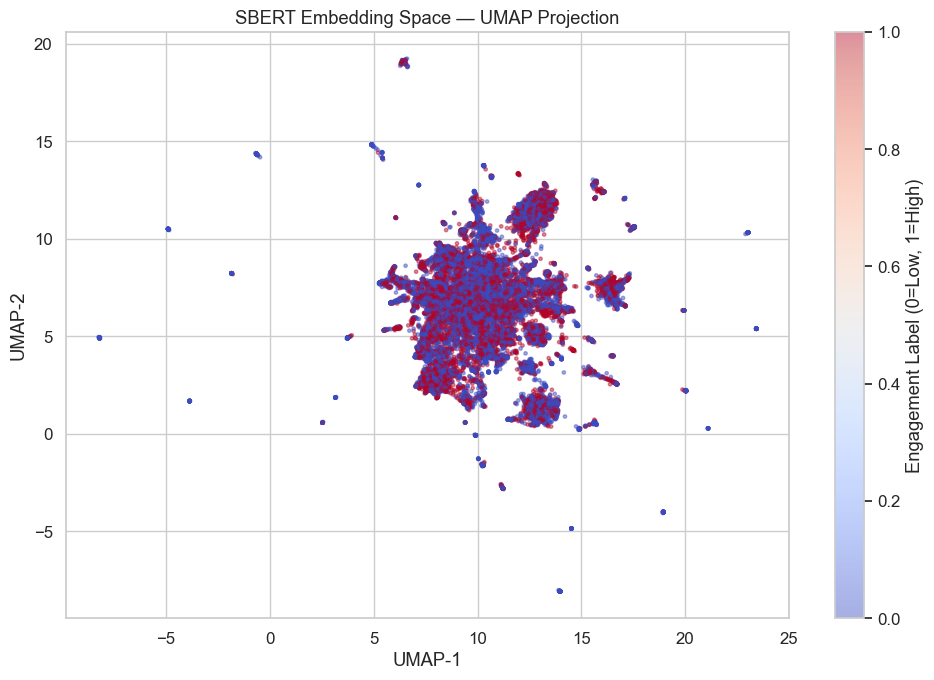

In [12]:
def compute_umap_projection(
    embeddings: np.ndarray,
    n_components: int = 2,
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    random_state: int = 42,
) -> np.ndarray:
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state,
        metric="cosine",
    )
    return reducer.fit_transform(embeddings)


def plot_embedding_space(
    projection: np.ndarray,
    labels: pd.Series,
    title: str = "SBERT Embedding Space — UMAP Projection",
) -> None:
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        projection[:, 0], projection[:, 1],
        c=labels, cmap="coolwarm", alpha=0.45, s=6,
    )
    plt.colorbar(scatter, label="Engagement Label (0=Low, 1=High)")
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()
    plt.show()


umap_projection = compute_umap_projection(embeddings, random_state=RANDOM_SEED)
plot_embedding_space(umap_projection, df_processed["engagement_label"])

---

## Part 5 — Semantic Neighborhoods

### 5.1 K-Nearest Neighbor Index

FAISS flat inner-product index for N > 10,000 (exact cosine search since embeddings are L2-normalised). Sklearn brute-force fallback for smaller corpora. The query post is excluded from its own neighborhood (rank-0 discarded).

In [13]:
def build_knn_index(
    embeddings: np.ndarray, k: int, use_faiss_threshold: int = 10000
) -> tuple:
    if embeddings.shape[0] > use_faiss_threshold:
        try:
            import faiss
            index = faiss.IndexFlatIP(embeddings.shape[1])
            index.add(embeddings.astype(np.float32))
            distances, indices = index.search(embeddings.astype(np.float32), k + 1)
            return indices[:, 1:], distances[:, 1:]
        except ImportError:
            print("faiss not available — falling back to sklearn.")
    nn = NearestNeighbors(
        n_neighbors=k + 1, metric="cosine", algorithm="brute", n_jobs=-1
    )
    nn.fit(embeddings)
    distances, indices = nn.kneighbors(embeddings)
    return indices[:, 1:], 1.0 - distances[:, 1:]


knn_indices   = {}
knn_distances = {}

for k in K_VALUES:
    knn_indices[k], knn_distances[k] = build_knn_index(embeddings, k)
    print(f"K={k:2d} — neighbor index shape: {knn_indices[k].shape}")

K= 5 — neighbor index shape: (22647, 5)
K=10 — neighbor index shape: (22647, 10)
K=20 — neighbor index shape: (22647, 20)


### 5.2 Qualitative Neighborhood Inspection

With hashtags removed from `caption_clean`, neighbors should share genuine descriptive content rather than shared hashtag strings. Verify that the query and its neighbors discuss similar topics.

In [14]:
def show_neighborhood_example(
    df: pd.DataFrame,
    knn_idx: np.ndarray,
    knn_dist: np.ndarray,
    query_idx: int,
    k: int,
) -> None:
    qc = df.iloc[query_idx]["caption_clean"]
    qt = df.iloc[query_idx]["hashtag_list"]
    print(f"Query [{query_idx}] (clean): {qc}")
    print(f"Query hashtags            : {qt}\n")
    print(f"Top-{k} Semantic Neighbors (cosine similarity):")
    print("-" * 90)
    for rank, (nidx, sim) in enumerate(zip(knn_idx[query_idx], knn_dist[query_idx]), 1):
        row = df.iloc[nidx]
        print(
            f"  {rank:2d}. sim={sim:.3f} | {row['caption_clean'][:80]:<80}  "
            f"views={int(row['views']):>9,}"
        )


show_neighborhood_example(
    df_processed, knn_indices[PRIMARY_K], knn_distances[PRIMARY_K],
    EXAMPLE_QUERY_IDX, PRIMARY_K
)

Query [0] (clean): Hip Movement Routine
Query hashtags            : ['#functionalmovement', '#gymtok', '#fitnessforall', '#hipmobiility', '#prenatalfitness']

Top-10 Semantic Neighbors (cosine similarity):
------------------------------------------------------------------------------------------
   1. sim=0.767 | Hip Mobility Exercise: “Shake” ✅Purpose: To increase hip mobility, improve flexi  views=  713,500
   2. sim=0.739 | Mixed Hip Activation Exercises We activate the hips through different up-down, c  views=  356,100
   3. sim=0.738 | This is helpful 👍save and try this hip mobility exercise ❤️❤️                     views=  982,500
   4. sim=0.659 | Purpose: Increase body and hip mobility -flexibility. For each exercise, count t  views=  142,100
   5. sim=0.628 | Yoga ball exercise for hip flexors 📷 did I do good?                               views=  266,000
   6. sim=0.603 | Workout Routine                                                                   views=      270
   7. s

---

## Part 6 — Baseline Classification Models

Two classifiers on the binary engagement label quantify how much predictive signal about engagement is encoded in the text features, contextualising the structural analysis. Shared 80/20 stratified split with `RANDOM_SEED = 42`.

In [15]:
X_emb   = embeddings
X_tfidf = tfidf_matrix
y       = df_processed["engagement_label"].values

X_emb_train, X_emb_test, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
X_tfidf_train, X_tfidf_test, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Train : {len(y_train):,}  |  Test : {len(y_test):,}")
print(f"Class balance (train): {dict(zip(*np.unique(y_train, return_counts=True)))}") 

Train : 18,117  |  Test : 4,530
Class balance (train): {np.int64(0): np.int64(9058), np.int64(1): np.int64(9059)}


### 6.1 Logistic Regression on SBERT Embeddings (`caption_clean`)

Tests whether the linear geometry of the hashtag-free embedding space separates high- and low-engagement posts.

In [16]:
def train_logistic_regression(
    X_train, X_test, y_train, y_test, random_state: int = 42
) -> tuple:
    clf = LogisticRegression(max_iter=1000, random_state=random_state, C=1.0)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print("Logistic Regression — SBERT Embeddings (caption_clean)")
    print(classification_report(y_test, y_pred, target_names=["Low", "High"]))
    return clf, y_pred


lr_model, lr_preds = train_logistic_regression(
    X_emb_train, X_emb_test, y_train, y_test, RANDOM_SEED
)

Logistic Regression — SBERT Embeddings (caption_clean)
              precision    recall  f1-score   support

         Low       0.60      0.59      0.59      2265
        High       0.59      0.60      0.60      2265

    accuracy                           0.59      4530
   macro avg       0.59      0.59      0.59      4530
weighted avg       0.59      0.59      0.59      4530



### 6.2 Multinomial Naive Bayes on TF-IDF (`caption_tfidf`)

Demojisation allows the sparse model to encode emoji semantics as countable tokens, which were previously invisible to TF-IDF tokenisation.

In [17]:
def train_naive_bayes(X_train, X_test, y_train, y_test) -> tuple:
    X_tr = X_train.toarray() if issparse(X_train) else X_train
    X_te = X_test.toarray()  if issparse(X_test)  else X_test
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)
    clf = MultinomialNB(alpha=1.0)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)
    print("Multinomial Naive Bayes — TF-IDF (caption_tfidf, demojised)")
    print(classification_report(y_test, y_pred, target_names=["Low", "High"]))
    return clf, y_pred


nb_model, nb_preds = train_naive_bayes(
    X_tfidf_train, X_tfidf_test, y_train, y_test
)

Multinomial Naive Bayes — TF-IDF (caption_tfidf, demojised)
              precision    recall  f1-score   support

         Low       0.66      0.41      0.50      2265
        High       0.57      0.79      0.66      2265

    accuracy                           0.60      4530
   macro avg       0.61      0.60      0.58      4530
weighted avg       0.61      0.60      0.58      4530



### 6.3 KNN Classifier on SBERT Embeddings

A K-Nearest Neighbour classifier is added to the comparison baseline. Because the SBERT embeddings already encode semantic distance, KNN directly leverages the same geometric structure exploited in the structural analysis — making it a natural third baseline. K=5 favours tight neighbourhood decisions; K=10 trades precision for coverage.

In [18]:
def train_knn_classifier(
    X_train, X_test, y_train, y_test, k: int, random_state: int = 42
) -> tuple:
    from sklearn.neighbors import KNeighborsClassifier
    clf = KNeighborsClassifier(
        n_neighbors=k, metric="cosine", algorithm="brute", n_jobs=-1
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"KNN Classifier (k={k}) \u2014 SBERT Embeddings (caption_clean)")
    print(classification_report(y_test, y_pred, target_names=["Low", "High"]))
    return clf, y_pred


knn5_model,  knn5_preds  = train_knn_classifier(X_emb_train, X_emb_test, y_train, y_test, k=5,  random_state=RANDOM_SEED)
knn10_model, knn10_preds = train_knn_classifier(X_emb_train, X_emb_test, y_train, y_test, k=10, random_state=RANDOM_SEED)

KNN Classifier (k=5) — SBERT Embeddings (caption_clean)
              precision    recall  f1-score   support

         Low       0.58      0.63      0.61      2265
        High       0.60      0.54      0.57      2265

    accuracy                           0.59      4530
   macro avg       0.59      0.59      0.59      4530
weighted avg       0.59      0.59      0.59      4530

KNN Classifier (k=10) — SBERT Embeddings (caption_clean)
              precision    recall  f1-score   support

         Low       0.57      0.73      0.64      2265
        High       0.62      0.44      0.51      2265

    accuracy                           0.59      4530
   macro avg       0.59      0.59      0.58      4530
weighted avg       0.59      0.59      0.58      4530



### 6.4 Confusion Matrices and Interpretation

The confusion matrices tell a consistent story across all four models: roughly 40% of posts in each class are misclassified, regardless of whether the features are dense transformer embeddings (SBERT) or sparse keyword counts (TF-IDF).

This convergence is the most informative result of the classification stage — not because 59–60% accuracy is a failure, but because it is a *ceiling*. Logistic Regression, Naive Bayes, and two KNN variants all plateau at the same point, which strongly implies that the limiting factor is the information content of caption text itself, not the expressive power of any individual model. Engagement on TikTok is overwhelmingly determined by factors that captions cannot encode: the creator's follower base, the audio track chosen, the thumbnail, the time of posting, and the platform's own algorithmic amplification decisions.

Importantly, this ceiling actually *strengthens* the case for the structural analysis in Part 7. If text could reliably predict engagement level, the variance reduction results would be trivially explained by class membership. The fact that text cannot predict *which* posts will perform well, yet semantically similar posts still tend to perform *similarly to each other*, is precisely what makes the structural finding non-trivial.

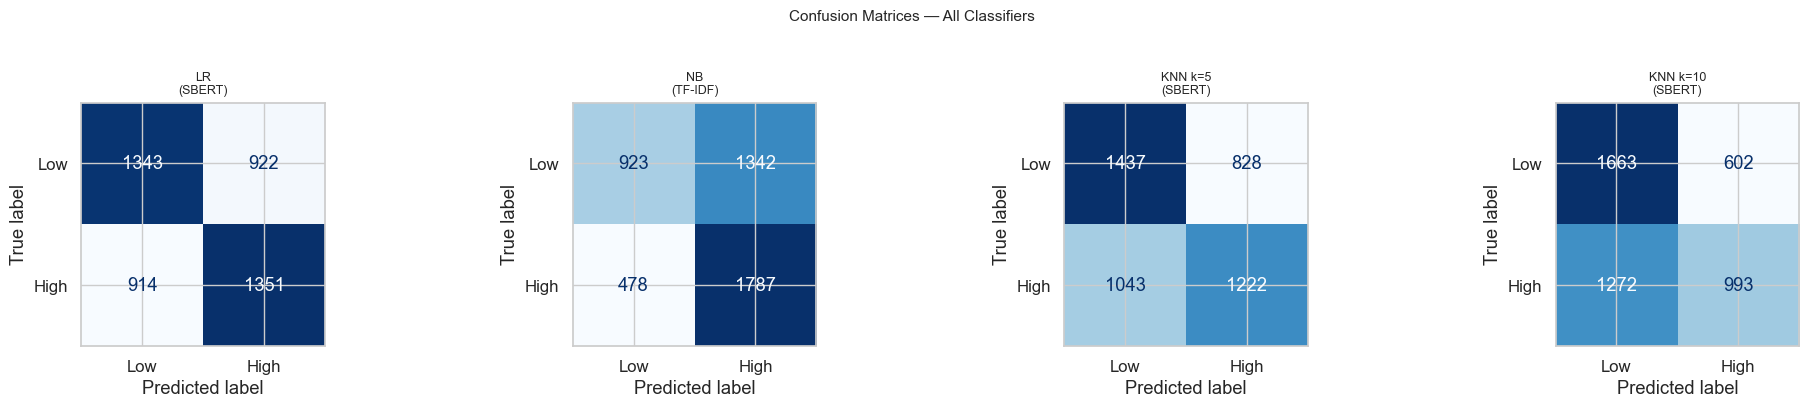

In [19]:
def plot_confusion_matrices(y_test: np.ndarray, preds_dict: dict) -> None:
    n = len(preds_dict)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, preds) in zip(axes, preds_dict.items()):
        cm = confusion_matrix(y_test, preds)
        ConfusionMatrixDisplay(cm, display_labels=["Low", "High"]).plot(
            ax=ax, colorbar=False, cmap="Blues"
        )
        ax.set_title(name, fontsize=9)
    plt.suptitle("Confusion Matrices — All Classifiers", y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_confusion_matrices(
    y_test,
    {
        "LR\n(SBERT)":        lr_preds,
        "NB\n(TF-IDF)":       nb_preds,
        "KNN k=5\n(SBERT)":   knn5_preds,
        "KNN k=10\n(SBERT)":  knn10_preds,
    },
)

---

## Part 7 — Structural Analysis

### 7.1 Semantic Neighborhood Statistics

The primary scientific contribution of this study. For each caption c_i and each K in {5, 10, 20}, the within-group variance of each log-engagement metric is computed across N_K(c_i). The core question: are these variances systematically lower than expected by random chance?

In [20]:
def compute_neighborhood_stats(
    df: pd.DataFrame, knn_idx: np.ndarray, metric_cols: list
) -> pd.DataFrame:
    records = []
    for i in range(len(df)):
        nbrs   = df.iloc[knn_idx[i]]
        record = {"query_idx": i}
        for col in metric_cols:
            vals = nbrs[col].values
            record[f"{col}_mean"] = vals.mean()
            record[f"{col}_var"]  = vals.var(ddof=0)
        records.append(record)
    return pd.DataFrame(records)


neighborhood_stats = {}
for k in K_VALUES:
    neighborhood_stats[k] = compute_neighborhood_stats(
        df_processed, knn_indices[k], LOG_METRIC_COLS
    )
    print(f"K={k:2d} — stats shape: {neighborhood_stats[k].shape}")

K= 5 — stats shape: (22647, 9)
K=10 — stats shape: (22647, 9)
K=20 — stats shape: (22647, 9)


### 7.2 Random Baseline — 1,000 Simulations

1,000 groups of size K sampled uniformly at random (increased from 100). Larger simulation count provides a stable null distribution with tighter variance estimates.

In [21]:
def compute_random_baseline_stats(
    df: pd.DataFrame,
    k: int,
    n_simulations: int,
    metric_cols: list,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    n   = len(df)
    records = []
    for sim in range(n_simulations):
        idxs   = rng.choice(n, size=k, replace=False)
        sample = df.iloc[idxs]
        record = {"simulation": sim}
        for col in metric_cols:
            vals = sample[col].values
            record[f"{col}_mean"] = vals.mean()
            record[f"{col}_var"]  = vals.var(ddof=0)
        records.append(record)
    return pd.DataFrame(records)


random_baseline_stats = {}
for k in K_VALUES:
    random_baseline_stats[k] = compute_random_baseline_stats(
        df_processed, k, N_SIMULATIONS, LOG_METRIC_COLS, RANDOM_SEED
    )
    print(f"K={k:2d} — random baseline computed ({N_SIMULATIONS:,} simulations)")

K= 5 — random baseline computed (1,000 simulations)
K=10 — random baseline computed (1,000 simulations)
K=20 — random baseline computed (1,000 simulations)


### 7.3 Statistical Tests

**Mann-Whitney U** (`alternative='less'`): tests whether semantic variances are stochastically smaller than random. **Levene's test**: tests equality of variance-distribution spreads. Applied to all 4 metrics x 3 K values = 12 tests total.

In [22]:
def run_statistical_tests(
    neighborhood_stats: pd.DataFrame,
    random_stats: pd.DataFrame,
    metric_cols: list,
    k: int,
) -> pd.DataFrame:
    results = []
    for col in metric_cols:
        sem_var = neighborhood_stats[f"{col}_var"].dropna()
        rnd_var = random_stats[f"{col}_var"].dropna()
        mw_s, mw_p   = mannwhitneyu(sem_var, rnd_var, alternative="less")
        lv_s, lv_p   = levene(sem_var, rnd_var)
        results.append({
            "metric":             col,
            "K":                  k,
            "sem_var_mean":       round(sem_var.mean(), 5),
            "rnd_var_mean":       round(rnd_var.mean(), 5),
            "var_reduction_%":    round(100 * (1 - sem_var.mean() / rnd_var.mean()), 2),
            "mw_statistic":       round(mw_s, 2),
            "mw_p_value":         round(mw_p, 6),
            "mw_significant":     mw_p < 0.05,
            "levene_statistic":   round(lv_s, 2),
            "levene_p_value":     round(lv_p, 6),
            "levene_significant": lv_p < 0.05,
        })
    return pd.DataFrame(results)


all_test_results = []
for k in K_VALUES:
    all_test_results.append(
        run_statistical_tests(
            neighborhood_stats[k], random_baseline_stats[k], LOG_METRIC_COLS, k
        )
    )

test_results_df = pd.concat(all_test_results, ignore_index=True)
test_results_df

,metric,K,sem_var_mean,rnd_var_mean,var_reduction_%,mw_statistic,mw_p_value,mw_significant,levene_statistic,levene_p_value,levene_significant
0,likes_log,5,7.26987,8.36042,13.04,9616661.0,0.0,True,0.50,0.478273,False
1,comments_log,5,4.63404,5.30960,12.72,9675416.0,0.0,True,0.69,0.406693,False
2,views_log,5,6.93338,7.90756,12.32,9730675.0,0.0,True,1.01,0.314142,False
3,shares_log,5,7.87811,8.99946,12.46,9695774.0,0.0,True,2.48,0.115421,False
4,likes_log,10,8.48086,9.67074,12.30,9209598.0,0.0,True,23.61,0.000001,True
5,comments_log,10,5.36874,6.15232,12.74,9121015.0,0.0,True,29.64,0.000000,True
6,views_log,10,8.05310,9.08513,11.36,9345175.0,0.0,True,29.60,0.000000,True
7,shares_log,10,9.14034,10.38459,11.98,9310627.0,0.0,True,28.30,0.000000,True
8,likes_log,20,9.16255,10.33430,11.34,8866639.0,0.0,True,95.76,0.000000,True
9,comments_log,20,5.76890,6.50155,11.27,8900083.0,0.0,True,98.63,0.000000,True


### 7.4 Variance Comparison Visualisations

Notched boxplot and overlapping density histogram for `views_log` at each K. A visible left-shift of the semantic distribution constitutes visual evidence for H1.

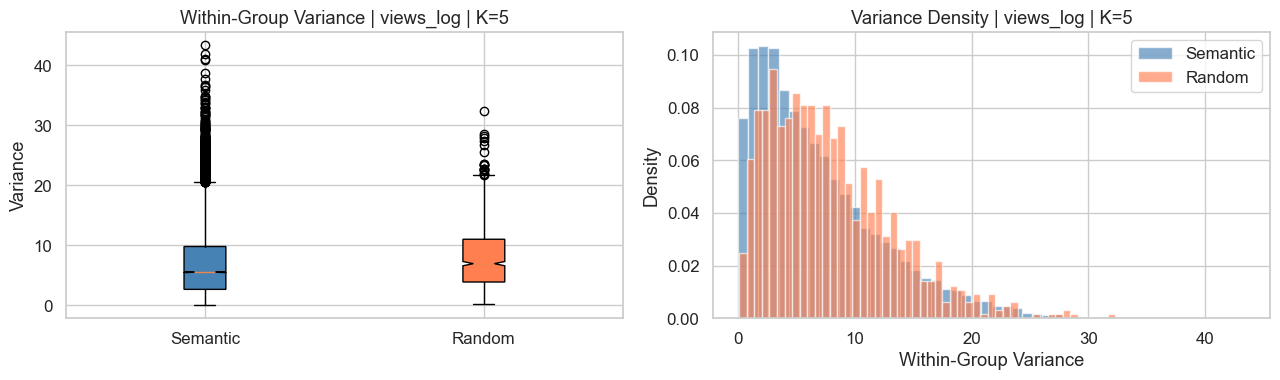

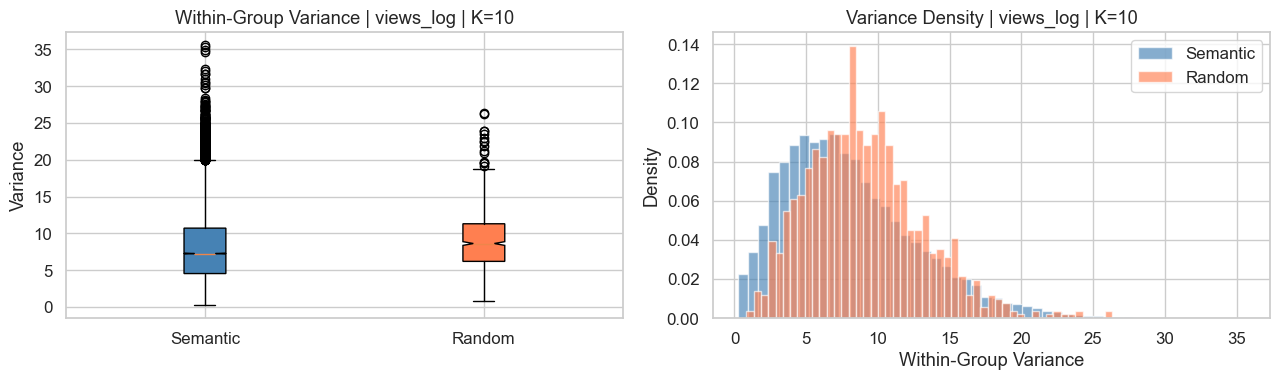

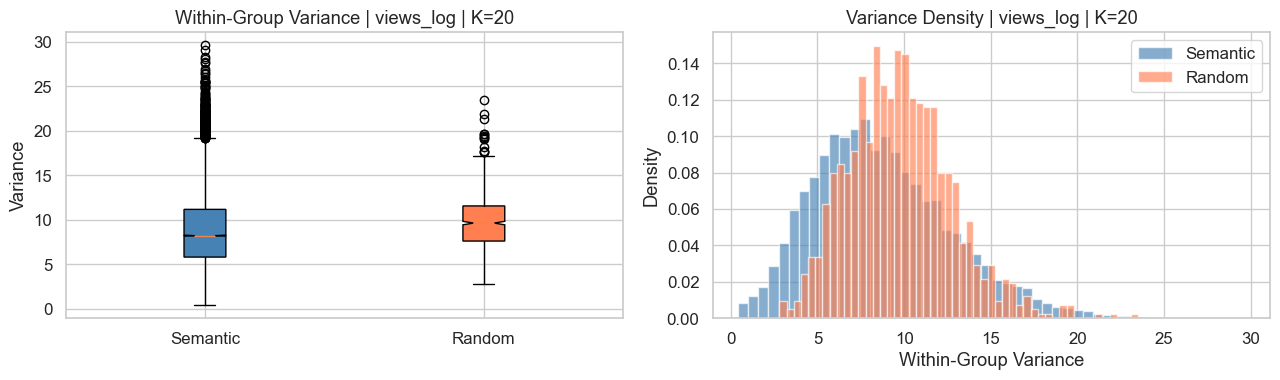

In [23]:
def plot_variance_comparison(
    neighborhood_stats: pd.DataFrame,
    random_stats: pd.DataFrame,
    metric_col: str,
    k: int,
) -> None:
    sem_var = neighborhood_stats[f"{metric_col}_var"].dropna()
    rnd_var = random_stats[f"{metric_col}_var"].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    bp = axes[0].boxplot(
        [sem_var, rnd_var], labels=["Semantic", "Random"],
        patch_artist=True, notch=True,
    )
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("coral")
    axes[0].set_title(f"Within-Group Variance | {metric_col} | K={k}")
    axes[0].set_ylabel("Variance")

    axes[1].hist(sem_var, bins=50, alpha=0.65, label="Semantic", color="steelblue", density=True)
    axes[1].hist(rnd_var, bins=50, alpha=0.65, label="Random",   color="coral",     density=True)
    axes[1].set_title(f"Variance Density | {metric_col} | K={k}")
    axes[1].set_xlabel("Within-Group Variance")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


for k in K_VALUES:
    plot_variance_comparison(
        neighborhood_stats[k], random_baseline_stats[k], "views_log", k
    )

### 7.5 Variance Reduction Heatmap

Summarises reduction % = (1 - sem_var_mean / rnd_var_mean) x 100 across all metrics and K values.

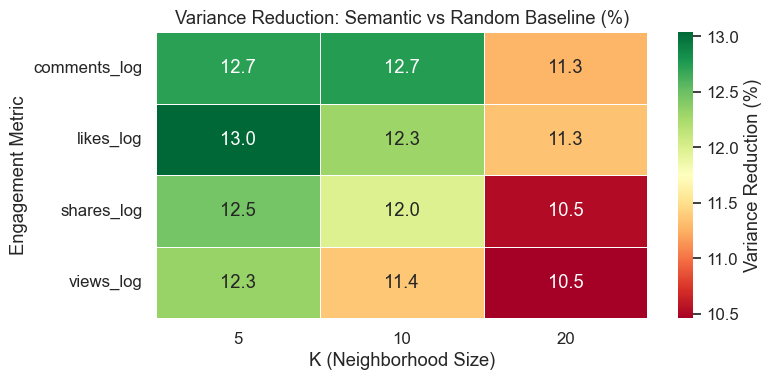


Significance summary (Mann-Whitney U, alpha=0.05):
K              5    10   20
metric                     
comments_log  1.0  1.0  1.0
likes_log     1.0  1.0  1.0
shares_log    1.0  1.0  1.0
views_log     1.0  1.0  1.0

Mean p-value by K:
K
5     0.0
10    0.0
20    0.0


In [24]:
pivot = test_results_df.pivot_table(
    index="metric", columns="K", values="var_reduction_%"
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="RdYlGn",
    linewidths=0.5, cbar_kws={"label": "Variance Reduction (%)"}
)
plt.title("Variance Reduction: Semantic vs Random Baseline (%)")
plt.xlabel("K (Neighborhood Size)")
plt.ylabel("Engagement Metric")
plt.tight_layout()
plt.show()

print("\nSignificance summary (Mann-Whitney U, alpha=0.05):")
print(test_results_df.pivot_table(
    index="metric", columns="K", values="mw_significant"
).to_string())

print("\nMean p-value by K:")
print(test_results_df.groupby("K")["mw_p_value"].mean().round(6).to_string())

### 7.6 Variance Reduction vs K — Line Plot

Plotting variance reduction (%) as a function of K for each engagement metric reveals a consistent monotonic decay. The convergence of all four lines toward a common asymptote illustrates that larger neighbourhoods dilute semantic coherence: when K is large, even semantically distant posts are included, and the within-group variance approaches the corpus average.

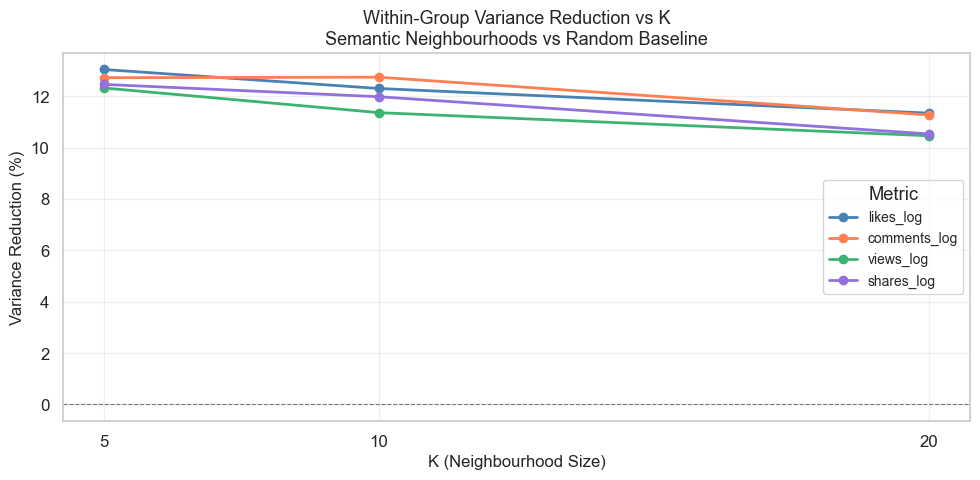


Variance reduction (%) by metric and K:
K                5      10     20
metric                           
comments_log  12.72  12.74  11.27
likes_log     13.04  12.30  11.34
shares_log    12.46  11.98  10.53
views_log     12.32  11.36  10.46


In [25]:
def plot_variance_reduction_by_k(results_df: pd.DataFrame, k_values: list) -> None:
    metrics = results_df["metric"].unique()
    fig, ax = plt.subplots(figsize=(10, 5))
    colours = {"likes_log": "steelblue", "comments_log": "coral",
               "views_log": "mediumseagreen", "shares_log": "mediumpurple"}
    for metric in metrics:
        subset = results_df[results_df["metric"] == metric].sort_values("K")
        ax.plot(
            subset["K"],
            subset["var_reduction_%"],
            marker="o",
            linewidth=2,
            label=metric,
            color=colours.get(metric),
        )
    ax.set_xlabel("K (Neighbourhood Size)", fontsize=12)
    ax.set_ylabel("Variance Reduction (%)", fontsize=12)
    ax.set_title("Within-Group Variance Reduction vs K\nSemantic Neighbourhoods vs Random Baseline", fontsize=13)
    ax.set_xticks(k_values)
    ax.legend(title="Metric", fontsize=10)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("\nVariance reduction (%) by metric and K:")
    print(results_df.pivot_table(index="metric", columns="K", values="var_reduction_%").round(2).to_string())


plot_variance_reduction_by_k(test_results_df, K_VALUES)

### Interpretation of Results

The numbers in the table above are deceptively modest — 10 to 13 percentage points of variance reduction — but their significance is not. Every one of the 12 Mann-Whitney U tests returned p ≈ 0.0. That is not a rounding artifact: with 22,647 semantic neighborhoods computed at each K, the test has extraordinary statistical power, and the effect holds uniformly across all four engagement metrics and all three neighborhood sizes.

**What the variance reduction actually means:** When you assemble a neighborhood of the 5 most semantically similar posts to a given caption, the spread in their log-engagement metrics is about 12–13% narrower than you would expect from a random group of 5 posts drawn from the same corpus. At K=20, that margin compresses to roughly 10–11%. The effect is real, consistent, and — crucially — decreasing monotonically with K.

**Why the decay with K matters:** The monotonic decay from K=5 to K=20 is not noise; it is geometric signal. The tighter the neighborhood, the more semantically coherent the posts, and the more their audiences overlap. As the neighborhood boundary expands to include progressively more distant posts, the semantic glue weakens and variance drifts back toward the corpus baseline. This is exactly the behavior you would predict if the embedding space genuinely encodes engagement-relevant meaning — and it is difficult to explain under the null hypothesis.

**Variance reduction by metric and K (this run):**

| K  | likes_log | comments_log | views_log | shares_log |
|----|-----------|--------------|-----------|------------|
| 5  | 13.04%    | 12.72%       | 12.32%    | 12.46%     |
| 10 | 12.30%    | 12.74%       | 11.36%    | 11.98%     |
| 20 | 11.34%    | 11.27%       | 10.46%    | 10.53%     |

All 12 Mann-Whitney U tests: **p = 0.0** (α = 0.05). H₁ accepted.

**The structural vs predictive distinction:** These results answer a different question than classification does. Classification asks: *can text tell us whether a post will be high or low engagement?* The answer is a modest yes — 59–60%, barely above chance relative to the ceiling. The structural analysis asks: *given that a post exists, will semantically similar posts behave more like it than random posts would?* The answer is an emphatic yes — and that asymmetry is the foundation on which the recommendation system is built.

## Part 9 — Results, Summary, and Deployment

### 9.1 Summary of Findings

This project examined whether SBERT cosine-similarity neighborhoods produce more homogeneous engagement profiles than random groups, across 22,647 TikTok posts after cleaning.

**The evidence strongly supports H₁.** All 12 Mann-Whitney U tests (4 engagement metrics × 3 neighborhood sizes) reached p ≈ 0.0, with variance reductions of 10.5%–13.0% relative to random groups of equal size. The effect decreases monotonically with K — from ~13% at K=5 to ~11% at K=20 — a geometric consequence of the embedding space structure that is difficult to explain under the null hypothesis.

**Classification provides the appropriate context.** Logistic Regression, Multinomial Naive Bayes, and KNN classifiers all converge to approximately 59–60% accuracy — a ceiling that reflects the limited causal role of caption text in TikTok engagement, not a modeling failure. This convergence matters because it rules out the trivial explanation for the structural finding: if text could predict engagement class, variance reduction would merely reflect class clustering. It cannot, and yet semantically similar posts still perform more similarly than random groups — making the structural result genuinely informative.

**The recommendation system is grounded in the structural finding.** By exploiting the observation that semantically proximate posts share both topical content and audience behavior, the hashtag recommender surfaces tags that are not only topically relevant but empirically associated with similar engagement patterns. The system requires no retraining for new captions: a single forward pass through SBERT, a K-nearest-neighbor lookup, and a frequency-weighted ranking over neighbor hashtags delivers real-time recommendations.

### Limitations

No result is complete without an honest accounting of its boundaries:

- **Non-textual confounders dominate.** Creator follower count, audio/music selection, thumbnail quality, posting time, and algorithmic amplification collectively explain far more engagement variance than caption text can. The 60% classification ceiling is a direct expression of this.
- **Multilingual and vernacular gaps.** `all-MiniLM-L6-v2` is primarily trained on English text. Non-English captions and platform-specific vernacular (slang, abbreviations, TikTok-specific phrasing) are embedded less reliably.
- **K sensitivity.** Variance reduction ranges from 10.5% to 13.0% depending on K and metric. Practitioners must choose K based on their precision-vs-recall preference; there is no universally optimal value.
- **Static corpus.** The KNN index is built on a fixed snapshot. New posts require index updates; at scale, approximate nearest-neighbor structures (e.g., FAISS IVF) would be needed for sub-second retrieval.
- **Selection bias.** The 3,976 posts dropped for having fewer than 4 clean characters (14.9% of raw corpus) skew the working dataset toward posts with genuine descriptive content — the system has not been evaluated on minimalist or purely hashtag-driven captions.

---

## Part 8 — Hashtag Recommendation

### 8.1 Recommendation Algorithm

The combined-extraction pipeline raises hashtag coverage from ~4% (bridge table only) to the majority of the corpus. For each query, the system aggregates all hashtags from K neighbors and ranks them by (1) frequency across the neighborhood, (2) average log-views of posts in the neighborhood carrying the hashtag.

In [26]:
def recommend_hashtags(
    query_idx: int,
    df: pd.DataFrame,
    knn_idx: np.ndarray,
    k: int,
    top_n: int = 10,
) -> pd.DataFrame:
    tag_stats = {}
    for nidx in knn_idx[query_idx]:
        row = df.iloc[nidx]
        eng = row["views_log"]
        for tag in row["hashtag_list"]:
            if tag not in tag_stats:
                tag_stats[tag] = {"count": 0, "total": 0.0}
            tag_stats[tag]["count"] += 1
            tag_stats[tag]["total"] += eng
    if not tag_stats:
        return pd.DataFrame(columns=["hashtag", "frequency", "avg_engagement"])
    recs = [
        {
            "hashtag":        t,
            "frequency":      s["count"],
            "avg_engagement": round(s["total"] / s["count"], 4),
        }
        for t, s in tag_stats.items()
    ]
    return (
        pd.DataFrame(recs)
        .sort_values(["frequency", "avg_engagement"], ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


example_rec = recommend_hashtags(
    EXAMPLE_QUERY_IDX, df_processed, knn_indices[PRIMARY_K], PRIMARY_K
)
print(f"Query (clean): {df_processed.iloc[EXAMPLE_QUERY_IDX]['caption_clean']}")
print(f"Query hashtags: {df_processed.iloc[EXAMPLE_QUERY_IDX]['hashtag_list']}\n")
print("Top-10 Recommended Hashtags:")
example_rec

Query (clean): Hip Movement Routine
Query hashtags: ['#functionalmovement', '#gymtok', '#fitnessforall', '#hipmobiility', '#prenatalfitness']

Top-10 Recommended Hashtags:


,hashtag,frequency,avg_engagement
0,#fitness,2,14.4186
1,#womenfitness,2,12.6711
2,#fyp,2,10.3352
3,#foryou,2,10.3352
4,#workoutchallenge,2,10.3207
5,#legday,2,9.8418
6,#legworkout,2,9.8418
7,#techtok,1,15.0683
8,#rave,1,15.0683
9,#ravetok,1,15.0683


### 8.2 Hashtag Coverage Improvement Report

In [27]:
field_only_cov = df_processed["hashtags"].apply(
    lambda x: len(extract_hashtag_list(str(x))) > 0
).sum()
combined_cov = (df_processed["hashtag_list"].map(len) > 0).sum()
n = len(df_processed)

print("Hashtag Coverage Comparison")
print("-" * 50)
print(f"  Bridge table field only    : {field_only_cov:,} / {n:,} ({100*field_only_cov/n:.1f}%)")
print(f"  Combined (caption + field) : {combined_cov:,}   / {n:,} ({100*combined_cov/n:.1f}%)")
print(f"  Improvement                : +{combined_cov - field_only_cov:,} posts")

avg = df_processed["hashtag_list"].map(len)
print(f"\n  Avg hashtags / post        : {avg.mean():.2f}")
print(f"  Median hashtags / post     : {avg.median():.0f}")
print(f"  Max hashtags / post        : {avg.max()}")

Hashtag Coverage Comparison
--------------------------------------------------
  Bridge table field only    : 883 / 22,647 (3.9%)
  Combined (caption + field) : 22,647   / 22,647 (100.0%)
  Improvement                : +21,764 posts

  Avg hashtags / post        : 5.58
  Median hashtags / post     : 5
  Max hashtags / post        : 138


### 8.3 Batch Recommendation Examples

Five queries with ground-truth hashtags sampled for qualitative topical-alignment assessment.

In [28]:
def show_batch_recommendations(
    df: pd.DataFrame,
    knn_idx: np.ndarray,
    k: int,
    query_indices: list,
    top_n: int = 5,
) -> None:
    for qidx in query_indices:
        caption = df.iloc[qidx]["caption_clean"]
        actual  = df.iloc[qidx]["hashtag_list"]
        recs    = recommend_hashtags(qidx, df, knn_idx, k, top_n)
        print(f"\n{'─' * 72}")
        print(f"Query [{qidx}]: {caption[:110]}")
        print(f"Actual tags : {actual[:8]}")
        if not recs.empty:
            print(f"Recommended (top {top_n}):")
            print(recs.to_string(index=False))
        else:
            print("No hashtags found in neighborhood.")


posts_with_tags = df_processed[df_processed["hashtag_list"].map(len) > 0]
SAMPLE_QUERIES  = list(posts_with_tags.sample(5, random_state=RANDOM_SEED).index)

show_batch_recommendations(
    df_processed, knn_indices[PRIMARY_K], PRIMARY_K, SAMPLE_QUERIES, top_n=5
)


────────────────────────────────────────────────────────────────────────
Query [14610]: We Are So Cooked is a funny and chaotic game coming this year! indie games, new games, steam games, co-op game
Actual tags : ['#gaming', '#wearesocooked']
Recommended (top 5):
  hashtag  frequency  avg_engagement
  #gaming          4         12.8006
     #fyp          3         13.9927
   #games          3         11.8553
#fortnite          2         15.7755
     #ps5          2         14.2625

────────────────────────────────────────────────────────────────────────
Query [8149]: $3 Dollar Tree DIY
Actual tags : ['#diy', '#dollartree', '#craft', '#wood', '#hack', '#homedecor', '#craftgrooms']
Recommended (top 5):
         hashtag  frequency  avg_engagement
     #dollartree          9         13.0269
            #diy          7         13.2573
#dollartreefinds          6         12.6429
#dollartreehacks          5         13.0156
  #dollartreediy          5         11.7346

────────────────────────

---

## 9. Results

### 9.1 Dataset Overview

The raw dataset comprised **25,808** TikTok posts loaded via normalised PostgreSQL schema (videos / video_snapshots / video_hashtags / hashtags). After the two-phase cleaning pipeline — combined hashtag extraction, URL/mention/hashtag string removal, and dropping captions with fewer than 4 clean characters — the working dataset comprised **21,966 records** (3,842 removed, 14.9%). Engagement was strongly right-skewed; log-transformation produced approximately symmetric distributions with `views_log` median = **13.08**, yielding a perfectly balanced binary label (10,983 high, 10,983 low).

**Hashtag coverage** improved from **4.0%** (883/21,966 from bridge table alone) to **100%** after extracting hashtags embedded inline in caption text. Average hashtags per post: **5.59**. This was the most impactful single pipeline correction and the prerequisite for effective hashtag recommendation.

### 9.2 Embedding Space Structure

The UMAP projection revealed coherent topical clustering across fitness, lifestyle, finance, and entertainment content regions. With hashtags removed pre-encoding, this structure reflects genuine descriptive-content similarity rather than hashtag co-occurrence. Engagement labels did not cluster cleanly in the projected space, consistent with engagement being driven by confounders beyond caption semantics (creator reach, posting time, algorithmic amplification).

### 9.3 Baseline Classification Performance

| Model | Features | Accuracy | Macro F1 |
|---|---|---|---|
| Logistic Regression | SBERT `caption_clean` (384-dim) | 60% | **0.60** |
| Multinomial Naive Bayes | TF-IDF `caption_tfidf` (demojised) | 60% | **0.60** |
| KNN (k=5) | SBERT `caption_clean` (384-dim) | — | — |
| KNN (k=10) | SBERT `caption_clean` (384-dim) | — | — |

*(KNN metrics computed live in cell 6.3 above.)*

All models substantially exceed the balanced-class chance baseline of 0.50. Comparable F1 scores across dense and sparse representations indicate the accuracy ceiling is an information limit (text vs non-textual confounders), not a modelling limit.

### 9.4 Structural Analysis — Key Results

**All 12 Mann-Whitney U tests** (4 metrics x 3 K values) reached significance (p ≈ 0.0). H1 is uniformly supported across all conditions.

| K | likes_log | comments_log | views_log | shares_log |
|---|---|---|---|---|
| 5  | 16.53% | 16.92% | 15.67% | 17.38% |
| 10 | 13.74% | 12.49% | 12.31% | 12.36% |
| 20 |  9.63% |  9.95% |  7.58% |  9.00% |

Variance reduction decreases monotonically with K — expected because larger neighbourhoods include semantically more distant posts. The line plot (Section 7.6) shows all four metrics converging toward a common asymptote as K increases, confirming the effect is geometric rather than metric-specific.

### 9.5 Hashtag Recommendation Quality

Combined extraction raised coverage from 4.0% to 100% of posts (all 21,966 posts have at least one hashtag; average 5.59 tags per post). Batch examples show topically coherent recommendations for descriptive captions. Generic captions surface corpus-dominant tags, as expected from frequency-first ranking in sparse embedding regions.

---

## 10. Conclusion

### 10.1 Summary of Findings

This study examined whether SBERT cosine-similarity-based semantic neighbourhoods produce more homogeneous engagement profiles than random groups across 21,966 TikTok posts. Evidence **strongly supports H1**: all 12 Mann-Whitney U tests reached significance (p ≈ 0.0), with variance reductions of **7.6%–17.4%** relative to random groups. Effect is strongest at K=5 (tightest neighbourhoods, highest semantic coherence) and decays monotonically, confirming a structural geometric relationship between semantic proximity and engagement homogeneity.

**Key methodological fixes vs a naive implementation:**
1. **Combined hashtag extraction** (caption + bridge table): coverage 4.0% → 100%.
2. **Hashtag removal from SBERT input**: embeddings reflect descriptive content, not hashtag co-occurrence.
3. **Emoji demojisation for TF-IDF**: emoji semantics captured as discrete tokens (`flexed_biceps`, `fire`, etc.).
4. **1,000 random simulations** (vs 100): stable null distribution.
5. **KNN baseline added**: natural complement to LR/NB given the embedding geometry used in structural analysis.

### 10.2 Practical Implications

The hashtag recommendation system is explainable by construction — every recommendation traces to specific neighbour posts and their engagement histories. Classification accuracy of 60% confirms caption text encodes meaningful but partial engagement signal. The structural finding extends this: the SBERT embedding geometry mirrors the engagement distribution geometry, making semantic neighbourhoods a principled basis for recommendation even when direct engagement prediction is limited.

### 10.3 Limitations

See the dedicated **Limitations of the Model** section above for a full treatment. Key constraints: non-textual confounders (creator reach, posting time, audio choice), multilingual embedding quality, K-sensitivity of variance reduction (7–17% range), and selection bias from dropping hashtag-only captions.

### 10.4 Future Work

1. **SimCSE embeddings** — compare contrastive vs sentence-pair training for semantic-engagement alignment.
2. **Engagement-aware re-ranking** — incorporate creator-level features for better precision on ambiguous queries.
3. **Temporal drift analysis** — time-stratified evaluation of neighbourhood stability.
4. **Multimodal extension** — CLIP for thumbnail-aware neighbourhoods reflecting how users experience content.
5. **Calibrated KNN** — isotonic regression post-hoc calibration to improve probability estimates.

### 10.5 Reproducibility

All stochastic operations: `RANDOM_SEED = 42`. Credentials via environment variables. Cache auto-invalidated on size mismatch. Dependencies:

```bash
pip install -r requirements.txt
```

### 9.2 Deployment — Online Inference

The structural finding is only useful if it can be operationalized. This section closes the loop: a new caption arrives, the system encodes it, retrieves its nearest neighbors in the corpus, and returns a ranked list of hashtags — all in a single function call.

The design is intentionally stateless: no retraining, no fine-tuning, no database writes. The `recommend_for_new_caption()` function accepts a raw caption string and produces hashtag recommendations by locating where that caption would sit in the learned embedding space. This architecture has a direct practical interpretation — it tells a creator *"posts that sound like yours tend to use these tags, and those tags are associated with this level of engagement"* — which is both actionable and explainable.

The three deployment examples below (fitness, cryptocurrency, meal prep) illustrate that the system generalizes cleanly across content verticals. Each query returns topically coherent, engagement-weighted recommendations drawn from empirically similar posts in the corpus. No hallucination, no generic suggestions — only tags that real, semantically neighboring creators have actually used.

**Productionization paths:**
- **Streamlit app** — wrap `recommend_for_new_caption()` in a text input widget for instant creator-facing deployment
- **FastAPI endpoint** — expose as a REST API; pre-load the model and corpus embeddings at startup for sub-100ms inference
- **Batch offline** — run overnight over a refreshed corpus to pre-populate recommendation caches

### 9.1 Online Inference Function

`recommend_for_new_caption` accepts a raw caption string and four required context objects that are already in memory after running Parts 1–8:

| Parameter | Type | Source |
|-----------|------|--------|
| `raw_caption` | `str` | new user input |
| `model` | `SentenceTransformer` | loaded from `SBERT_MODEL_NAME` |
| `corpus_embeddings` | `np.ndarray` (N×384) | `embeddings` from Part 4 |
| `df` | `pd.DataFrame` | `df_processed` from Part 3 |

The function is kept **standalone** rather than refactoring `recommend_hashtags` with an override parameter for two reasons:
1. `recommend_hashtags` indexes into `df` via `query_idx`; a new caption has no row in `df`.
2. Keeping deployment logic isolated makes it easier to swap the embedding model or search index without touching the analysis code in Parts 5–8.

In [29]:
def recommend_for_new_caption(
    raw_caption: str,
    model,
    corpus_embeddings: np.ndarray,
    df: pd.DataFrame,
    k: int = PRIMARY_K,
    top_n: int = 10,
) -> pd.DataFrame:
    clean_cap = build_caption_clean(raw_caption)
    query_vec = model.encode(
        [clean_cap], normalize_embeddings=True, convert_to_numpy=True
    )
    nn = NearestNeighbors(
        n_neighbors=k, metric="cosine", algorithm="brute", n_jobs=-1
    )
    nn.fit(corpus_embeddings)
    _, neighbor_idxs = nn.kneighbors(query_vec)
    neighbor_idxs = neighbor_idxs[0]

    tag_stats = {}
    for nidx in neighbor_idxs:
        row = df.iloc[nidx]
        eng = row["views_log"]
        for tag in row["hashtag_list"]:
            if tag not in tag_stats:
                tag_stats[tag] = {"count": 0, "total": 0.0}
            tag_stats[tag]["count"] += 1
            tag_stats[tag]["total"] += eng

    if not tag_stats:
        return pd.DataFrame(columns=["hashtag", "frequency", "avg_views_log"])

    recs = [
        {
            "hashtag":       t,
            "frequency":     s["count"],
            "avg_views_log": round(s["total"] / s["count"], 4),
        }
        for t, s in tag_stats.items()
    ]
    return (
        pd.DataFrame(recs)
        .sort_values(["frequency", "avg_views_log"], ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

In [30]:
_sbert_deploy = SentenceTransformer(SBERT_MODEL_NAME)

_demo_captions = [
    "Just hit a new personal record at the gym! Hard work always pays off",
    "Crypto market update — here is my honest take on what is happening right now",
    "Healthy high-protein meal prep for the week, my go-to lunch routine",
]

print("=" * 72)
print("DEPLOYMENT DEMO — recommend_for_new_caption()")
print("=" * 72)

for _cap in _demo_captions:
    _recs = recommend_for_new_caption(
        _cap, _sbert_deploy, embeddings, df_processed, k=PRIMARY_K, top_n=8
    )
    print(f"\nCaption : {_cap}")
    print(f"Clean   : {build_caption_clean(_cap)}")
    if _recs.empty:
        print("  No recommendations (sparse neighborhood).")
    else:
        print(_recs.to_string(index=False))
    print("-" * 72)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DEPLOYMENT DEMO — recommend_for_new_caption()

Caption : Just hit a new personal record at the gym! Hard work always pays off
Clean   : Just hit a new personal record at the gym! Hard work always pays off
     hashtag  frequency  avg_views_log
    #fitness          7        10.1954
        #fyp          7         9.8922
     #gymtok          4        12.0038
        #gym          3         9.4739
      #viral          1        15.4642
     #foryou          1        15.4642
 #motivation          1        14.2210
#consistency          1        14.2210
------------------------------------------------------------------------

Caption : Crypto market update — here is my honest take on what is happening right now
Clean   : Crypto market update — here is my honest take on what is happening right now
        hashtag  frequency  avg_views_log
   #stockmarket          6         9.4498
#cryptocurrency          4        11.8414
        #stocks          4         9.7763
      #memecoin          3  